### Kernel: Python

# DeepSurv para cancer de mama - Arquiteturas variadas

Impacto de diferentes arquiteturas (número de camadas e neurônios) no desempenho do modelo DeepSurv.

In [1]:
# Configuracoes e imports
from pathlib import Path
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

SEED = 2003
EPOCHS = 5000
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
VALID_FRAC = 0.2

np.random.seed(SEED)
torch.manual_seed(SEED)

# Arquiteturas para testar
ARCHITECTURES = {
    "Arch_1": (64, 32),           # Original
    "Arch_2": (512, 512),         # Larga
    "Arch_3": (512, 256, 128),    # Profunda
    "Arch_4": (1024, 512, 256)    # Larga e Profunda
}

# Mapeamento de nomes para exibição no gráfico
DISPLAY_NAMES = {
    "Arch_1": "Arquitetura 1",
    "Arch_2": "Arquitetura 2",
    "Arch_3": "Arquitetura 3",
    "Arch_4": "Arquitetura 4"
}


## Carregamento dos dados

Usa os arquivos imputados (treino e teste) gerados no pre-processamento.

In [2]:
# Leitura dos dados
df_treino = pd.read_csv("../../../dados/dados-processados/dados_treino.csv")
df_teste = pd.read_csv("../../../dados/dados-processados/dados_teste.csv")

df_treino.head()

,rhc_raca_cor,instrucao,est_cong,rhc_historico_familiar_cancer,rhc_historico_alcool,rhc_historico_tabaco,rhc_origem_encamiamento,rhc_estadiamento_clinico,rhc_primeiro_tratamento_recebido_no_hospital_nenhum,rhc_primeiro_tratamento_recebido_no_hospital_cirurgia,...,macroregiao,pndr_renda,faixa_etcat,ano,tipo_hcido,id_paciente,diff_data_1consulta,diff_data_tratamento,tempo,delta_t
0,Branca,0,2,Não,Nunca,Nunca,Não SUS,III e IV,Não,Sim,...,3,Média Renda,5,2014,8500,1,12,42.0,16,1
1,Não Branca,0,2,Não,Nunca,Sim,SUS,III e IV,Não,Sim,...,3,Média Renda,5,2012,8500,2,-104,69.0,60,1
2,Não Branca,1,2,Não,Nunca,Nunca,SUS,III e IV,Não,Sim,...,1,Baixa Renda,1,2010,8500,5,83,99.0,69,1
3,Não Branca,1,2,Sim,Nunca,Sim,SUS,III e IV,Não,Não,...,1,Alta Renda,2,2017,min100,6,-10,46.0,7,1
4,Não Branca,1,2,Não,Nunca,Nunca,SUS,III e IV,Não,Não,...,3,Média Renda,1,2016,8500,7,52,91.0,27,1


## Preparacao da entrada da rede

Remove colunas de ID, tempo e evento das covariaveis.
One-hot para categoricas.
Numericas padronizadas com dados da base de treino.

In [3]:
# Colunas basicas
COL_ID = "id_paciente"
COL_TIME = "tempo"
COL_EVENT = "delta_t"

feature_cols = [c for c in df_treino.columns if c not in [COL_ID, COL_TIME, COL_EVENT]]

# Split treino/validacao (estratificado pelo evento)
df_tr, df_val = train_test_split(
    df_treino,
    test_size=VALID_FRAC,
    random_state=SEED,
    stratify=df_treino[COL_EVENT]
)

def build_design_matrices(df_train, df_other, feature_cols):
    X_train_raw = df_train[feature_cols].copy()
    X_other_raw = df_other[feature_cols].copy()

    # Detecta colunas numericas no treino
    numeric_cols = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()

    # One-hot nas categoricas (dummy_na para consistencia)
    X_train = pd.get_dummies(X_train_raw, dummy_na=True)
    X_other = pd.get_dummies(X_other_raw, dummy_na=True)

    # Alinha colunas com base no treino (categorias novas no teste sao ignoradas)
    X_train, X_other = X_train.align(X_other, join="left", axis=1, fill_value=0.0)

    # Padroniza apenas colunas numericas originais (presentes em X_train)
    stats = {}
    for col in numeric_cols:
        if col in X_train.columns:
            mean = X_train[col].mean()
            std = X_train[col].std(ddof=0)
            std = std if std > 0 else 1.0
            X_train[col] = (X_train[col] - mean) / std
            X_other[col] = (X_other[col] - mean) / std
            stats[col] = {"mean": float(mean), "std": float(std)}

    return X_train, X_other, stats

X_tr, X_val, stats_num = build_design_matrices(df_tr, df_val, feature_cols)
_, X_test, _ = build_design_matrices(df_tr, df_teste, feature_cols)

# Tensores para treinamento
X_tr_t = torch.tensor(X_tr.values.astype(np.float32))
X_val_t = torch.tensor(X_val.values.astype(np.float32))

times_tr = df_tr[COL_TIME].astype(float).values
events_tr = df_tr[COL_EVENT].astype(int).values
times_val = df_val[COL_TIME].astype(float).values
events_val = df_val[COL_EVENT].astype(int).values

print(f"X_tr shape: {X_tr_t.shape}, eventos: {events_tr.sum()}")
print(f"X_val shape: {X_val_t.shape}, eventos: {events_val.sum()}")

X_tr shape: torch.Size([3888, 60]), eventos: 460
X_val shape: torch.Size([973, 60]), eventos: 115


## Definição do modelo e Funções de Apoio

A saída é o log-risco (log hazard ratio). A funcao de perda é a log-verossimilhanca parcial de Cox (forma negativa).

In [4]:
class DeepSurvNet(nn.Module):
    def __init__(self, input_dim, hidden_dims=(64, 32), dropout=0.2):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)

def neg_partial_log_likelihood(log_h, times, events):
    order = np.argsort(-times)
    log_h = log_h[order]
    events = events[order]

    risk = torch.exp(log_h)
    log_cum_risk = torch.log(torch.cumsum(risk, dim=0))
    event_mask = torch.tensor(events.astype(np.float32), device=log_h.device)

    loss = -torch.sum((log_h - log_cum_risk) * event_mask)
    denom = event_mask.sum() + 1e-8
    return loss / denom

def concordance_index(times, events, risks):
    n = 0
    n_conc = 0
    for i in range(len(times)):
        for j in range(i + 1, len(times)):
            if events[i] == 1 and times[i] < times[j]:
                n += 1
                n_conc += 1 if risks[i] > risks[j] else 0
            elif events[j] == 1 and times[j] < times[i]:
                n += 1
                n_conc += 1 if risks[j] > risks[i] else 0
    return n_conc / n if n > 0 else np.nan

## Funções de Baseline e Predição

In [5]:
def breslow_baseline(times, events, risks):
    order = np.argsort(times)
    times, events, risks = times[order], events[order], risks[order]

    unique_times = np.unique(times[events == 1])
    cum_hazard = []
    h = 0.0
    for t in unique_times:
        idx_event = (times == t) & (events == 1)
        d_t = idx_event.sum()
        if d_t == 0:
            continue
        risk_set = risks[times >= t].sum()
        h += d_t / max(risk_set, 1e-12)
        cum_hazard.append(h)
    return unique_times, np.array(cum_hazard)

def baseline_survival_at(query_times, base_times, cum_hazard):
    query_times = np.asarray(query_times, dtype=float)
    surv = np.ones_like(query_times, dtype=float)
    if len(base_times) == 0:
        return surv
    mask = query_times >= base_times[0]
    idx = np.searchsorted(base_times, query_times[mask], side="right") - 1
    idx = np.clip(idx, 0, len(cum_hazard) - 1)
    surv[mask] = np.exp(-cum_hazard[idx])
    return surv

## Treinamento e Avaliação das Arquiteturas

Itera sobre as arquiteturas definidas, treina um modelo para cada uma e salva as predições.

In [6]:
all_results = {}
dir_saida = Path("../dados/saida")
dir_saida.mkdir(parents=True, exist_ok=True)

for arch_name, hidden_dims in ARCHITECTURES.items():
    print(f"--- Treinando arquitetura: {arch_name} {hidden_dims} ---")

    # Inicializacao do modelo
    model = DeepSurvNet(input_dim=X_tr_t.shape[1], hidden_dims=hidden_dims, dropout=0.2)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_epoch = -1
    
    # Loop de treino
    for epoch in range(EPOCHS):
        model.train()
        optimizer.zero_grad()
        log_h_tr = model(X_tr_t)
        loss_tr = neg_partial_log_likelihood(log_h_tr, times_tr, events_tr)
        loss_tr.backward()
        optimizer.step()
        train_losses.append(loss_tr.item())

        model.eval()
        with torch.no_grad():
            log_h_val = model(X_val_t)
            loss_val = neg_partial_log_likelihood(log_h_val, times_val, events_val)
            val_losses.append(loss_val.item())
        
        if loss_val.item() < best_val_loss:
            best_val_loss = loss_val.item()
            best_epoch = epoch
            torch.save(model.state_dict(), f"best_model_{arch_name}.pt")

        if (epoch + 1) % 100 == 0:
            print(f"Epoch {epoch + 1:4d}/{EPOCHS} | loss_tr={loss_tr.item():.4f} | loss_val={loss_val.item():.4f}")

    # Carrega o melhor modelo
    model.load_state_dict(torch.load(f"best_model_{arch_name}.pt"))
    
    # Avaliacao final com o melhor modelo
    model.eval()
    with torch.no_grad():
        risk_tr = torch.exp(model(X_tr_t)).cpu().numpy()
        risk_val = torch.exp(model(X_val_t)).cpu().numpy()
    c_tr = concordance_index(times_tr, events_tr, risk_tr)
    c_val = concordance_index(times_val, events_val, risk_val)
    
    print(f"Melhor época: {best_epoch + 1} | C-index Treino: {c_tr:.4f} | C-index Val: {c_val:.4f}")
    all_results[arch_name] = {
        'c_tr': c_tr, 
        'c_val': c_val, 
        'best_epoch': best_epoch + 1, 
        'hidden_dims': hidden_dims,
        'train_losses': train_losses,
        'val_losses': val_losses
    }

    # --- Predicao e Exportacao ---
    
    # Baseline a partir do treino
    base_times, cum_hazard = breslow_baseline(times_tr, events_tr, risk_tr)

    # Grid de tempos para avaliacao
    tempos_avaliacao_teste = np.arange(1, 132, 1)

    # Base por paciente no teste
    base_ids = df_teste[[COL_ID] + feature_cols].drop_duplicates().sort_values(COL_ID)
    X_ids = pd.get_dummies(base_ids[feature_cols], dummy_na=True)
    X_ids, _ = X_ids.align(pd.DataFrame(columns=X_tr.columns), join="right", axis=1, fill_value=0.0)

    for col, stats in stats_num.items():
        if col in X_ids.columns:
            X_ids[col] = (X_ids[col] - stats["mean"]) / stats["std"]

    X_ids_t = torch.tensor(X_ids.values.astype(np.float32))
    with torch.no_grad():
        risk_ids = torch.exp(model(X_ids_t)).cpu().numpy().reshape(-1)

    S0_grid = baseline_survival_at(tempos_avaliacao_teste, base_times, cum_hazard)

    linhas = []
    for idx, id_pac in enumerate(base_ids[COL_ID].values):
        s_ind = S0_grid ** risk_ids[idx]
        for t, s in zip(tempos_avaliacao_teste, s_ind):
            linhas.append({"ID": int(id_pac), "TIME": float(t), "PRED_S": float(s)})

    pred_out = pd.DataFrame(linhas).sort_values(["ID", "TIME"]).reset_index(drop=True)
    
    arquivo_saida = dir_saida / f"predicao-deepsurv-arch-{arch_name}.csv"
    pred_out.to_csv(arquivo_saida, index=False)
    print(f"Predições salvas em: {arquivo_saida}\n")

# Salva os resultados consolidados
with open(dir_saida / "resultados_arquiteturas.json", "w") as f:
    json.dump(all_results, f, indent=4)

--- Treinando arquitetura: Arch_1 (64, 32) ---
Epoch  100/5000 | loss_tr=7.5311 | loss_val=6.3066
Epoch  200/5000 | loss_tr=7.1731 | loss_val=6.3475
Epoch  300/5000 | loss_tr=6.9866 | loss_val=6.4939
Epoch  400/5000 | loss_tr=6.7380 | loss_val=6.6240
Epoch  500/5000 | loss_tr=6.6562 | loss_val=6.7933
Epoch  600/5000 | loss_tr=6.5788 | loss_val=7.0459
Epoch  700/5000 | loss_tr=6.4739 | loss_val=7.1770
Epoch  800/5000 | loss_tr=6.3898 | loss_val=7.3869
Epoch  900/5000 | loss_tr=6.4302 | loss_val=7.5858
Epoch 1000/5000 | loss_tr=6.2152 | loss_val=7.6894
Epoch 1100/5000 | loss_tr=6.1794 | loss_val=7.8464
Epoch 1200/5000 | loss_tr=6.1578 | loss_val=8.0663
Epoch 1300/5000 | loss_tr=6.1615 | loss_val=8.1903
Epoch 1400/5000 | loss_tr=6.0758 | loss_val=8.3419
Epoch 1500/5000 | loss_tr=6.0476 | loss_val=8.5102
Epoch 1600/5000 | loss_tr=6.0190 | loss_val=8.6974
Epoch 1700/5000 | loss_tr=5.9241 | loss_val=8.8520
Epoch 1800/5000 | loss_tr=5.9374 | loss_val=9.1627
Epoch 1900/5000 | loss_tr=5.9080 | 

## Análise dos Resultados

Resultados Consolidados (C-index):
            c_tr     c_val  best_epoch
Arch_3  0.795378  0.745478          29
Arch_2  0.798509  0.743890          27
Arch_4  0.792102  0.736199          18
Arch_1  0.819505  0.729522         139


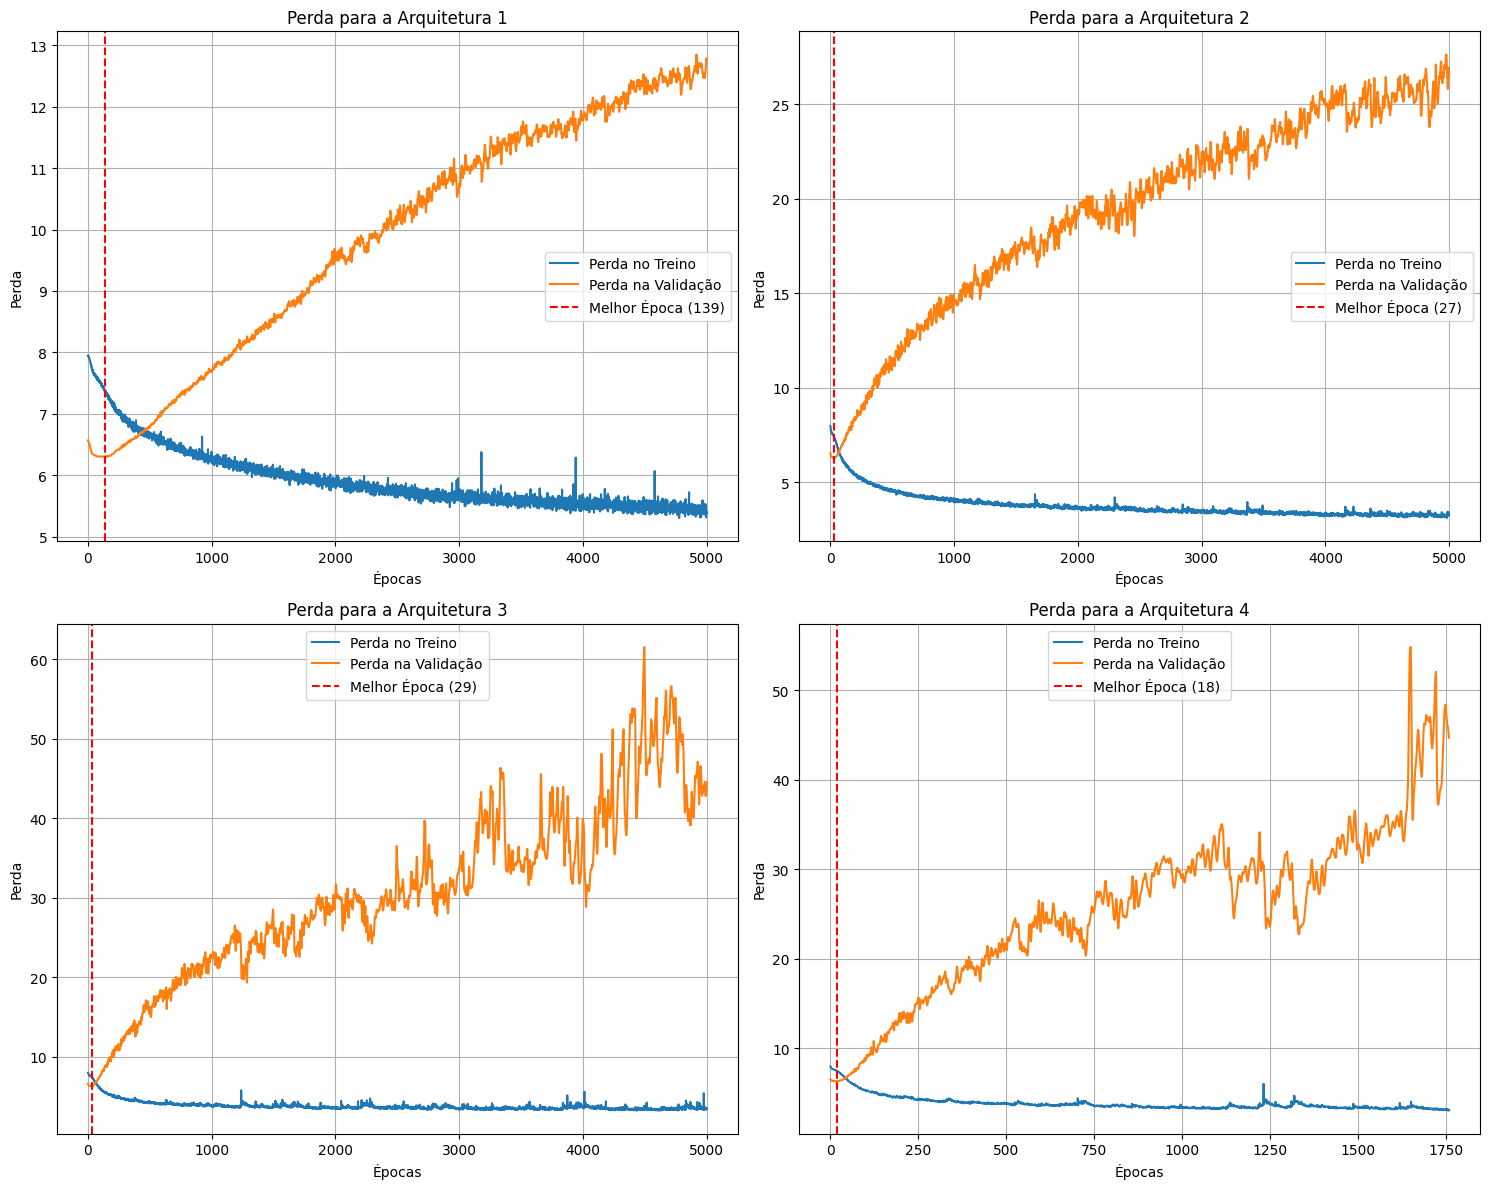

In [7]:
# Carrega e exibe os resultados
results_df = pd.DataFrame.from_dict(all_results, orient='index')
results_df = results_df.sort_values('c_val', ascending=False)
print("Resultados Consolidados (C-index):")
print(results_df[['c_tr', 'c_val', 'best_epoch']])

# Plot das perdas
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

for i, (arch_name, data) in enumerate(all_results.items()):
    ax = axes[i]
    display_name = DISPLAY_NAMES.get(arch_name, arch_name)
    ax.plot(data['train_losses'], label='Perda no Treino')
    ax.plot(data['val_losses'], label='Perda na Validação')
    ax.axvline(x=data['best_epoch'], color='r', linestyle='--', label=f'Melhor Época ({data["best_epoch"]})')
    ax.set_title(f'Perda para a {display_name}')
    ax.set_xlabel('Épocas')
    ax.set_ylabel('Perda')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()
